### Funções Auxiliares

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [103]:
def filter_valid_ratings(df: pd.DataFrame) -> pd.DataFrame:
    tamanho_original = len(df)
    
    df = df.dropna(subset=["geek_rating"]).copy()

    n_zero = (df["geek_rating"] == 0).sum()
    df = df[df["geek_rating"] > 0].copy()
    
    print(f"[filter_ratings] Linhas reduzidas de {tamanho_original} para {len(df)} (apenas com rating válido).")
    print(f"[filter_ratings] {n_zero:,} linha(s) com geek_rating == 0 removidas (sem votos suficientes no BGG, não é rating real).")
    return df

In [104]:
def clean_numeric_columns(df):
    num_cols = ["geek_rating"]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
 
    print(f"[numeric] {num_cols} convertidos")
    return df

In [105]:
def clean_num_players(df: pd.DataFrame) -> pd.DataFrame:
    def parse_players(s):
        if pd.isna(s):
            return pd.NA, pd.NA
        nums = re.findall(r"\d+", str(s))
        if len(nums) == 0:
            return pd.NA, pd.NA
        if len(nums) == 1:
            return int(nums[0]), int(nums[0])
        return int(nums[0]), int(nums[1])
 
    parsed = df["num_players"].apply(parse_players)
    df["min_players"] = parsed.apply(lambda x: x[0]).astype("Int64")
    df["max_players"] = parsed.apply(lambda x: x[1]).astype("Int64")
    df.drop(columns=["num_players"], inplace=True)
    print("[num_players] min_players / max_players extraídos")
    return df

In [106]:
def clean_play_time(df: pd.DataFrame) -> pd.DataFrame:
    def parse_time(s):
        if pd.isna(s):
            return pd.NA, pd.NA
        nums = re.findall(r"\d+", str(s))
        if len(nums) == 0:
            return pd.NA, pd.NA
        if len(nums) == 1:
            return int(nums[0]), int(nums[0])
        return int(nums[0]), int(nums[1])
 
    parsed = df["play_time"].apply(parse_time)
    df["min_time"] = parsed.apply(lambda x: x[0]).astype("Int64")
    df["max_time"] = parsed.apply(lambda x: x[1]).astype("Int64")
    df.drop(columns=["play_time"], inplace=True)
    print("[play_time] min_time / max_time extraídos")
    return df

In [107]:
def clean_suggested_age(df: pd.DataFrame) -> pd.DataFrame:
    df["min_suggested_age"] = (
        df["suggested_age"]
        .str.replace(r"\D", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")
        .astype("Int64")
    )
    df.drop(columns=["suggested_age"], inplace=True)
    
    print(f"[age] min_suggested_age — NaN: {df['min_suggested_age'].isna().sum():,}")
    return df

In [108]:
def clean_complexity(df: pd.DataFrame) -> pd.DataFrame:
    df["complexity"] = (
        df["complexity"]
        .str.extract(r"([\d.]+)\s*/\s*5")[0]
        .pipe(pd.to_numeric, errors="coerce")
    )
    print(f"[complexity] NaN: {df['complexity'].isna().sum():,}")
    return df

In [109]:
def normalize_list_columns(df: pd.DataFrame) -> pd.DataFrame:
    LIST_COLUMNS = ["categories", "mechanisms"]
    
    for col in LIST_COLUMNS:
        df[col] = df[col].apply(
            lambda x: [item.strip() for item in str(x).split(" / ")]
            if pd.notna(x) else []
        )
    print(f"[lists] {LIST_COLUMNS} convertidos para listas")
    return df

In [110]:
def clean_publishers(df: pd.DataFrame) -> pd.DataFrame:
    if "publishers" in df.columns:
        df["publishers"] = df["publishers"].apply(
            lambda x: str(x).split(" / ")[0].strip() if pd.notna(x) else pd.NA
        )
        print("[publishers] Primeira publisher extraída")
    return df

In [111]:
def clean_relationships(df: pd.DataFrame) -> pd.DataFrame:
    if "relationship" in df.columns:
        mask_expansion = df["relationship"].str.contains("Expansion for", na=False, case=False)
        
        df = df[~(mask_expansion) | df["relationship"].isna()].copy()
        
        df.drop(columns=["relationship"], inplace=True) 
        
        print("[relationship] Linhas com 'Expansion for' removidas")
    return df

In [112]:
def drop_unnecessary_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols_to_drop = ["artists", "developer", "rank", "designers", "avg_rating", "price", "num_voters", "year"]
    existing_cols = [c for c in cols_to_drop if c in df.columns]
    
    if existing_cols:
        df.drop(columns=existing_cols, inplace=True)
        print(f"[drop] Colunas removidas: {existing_cols}")
    return df

In [113]:
def drop_falha_rows(df: pd.DataFrame) -> pd.DataFrame:
    mask = df.apply(
        lambda col: col.astype(str).str.contains(r'\bFalha\b', case=False, na=False)
    ).any(axis=1)

    n_removed = mask.sum()
    df = df[~mask].copy()
    print(f"[drop_falha] {n_removed:,} linha(s) contendo 'Falha' removida(s).")
    return df

In [114]:
def encode_publishers(df: pd.DataFrame) -> pd.DataFrame:
    pub_freq = df['publishers'].value_counts(normalize=True)
    
    df['publisher_freq'] = df['publishers'].map(pub_freq)
    
    df.drop(columns=['publishers'], inplace=True)
    print("[Encoder] Publishers convertidos para frequência.")
    return df

In [115]:
def drop_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    n_antes = len(df)
    df = df.drop_duplicates().copy()
    n_removidas = n_antes - len(df)
    print(f"[duplicates] {n_removidas:,} linha(s) duplicada(s) removida(s).")
    return df

In [116]:
def fix_min_max_inconsistencies(df: pd.DataFrame) -> pd.DataFrame:

    pares = [("min_players", "max_players"), ("min_time", "max_time")]

    for min_col, max_col in pares:
        mask = df[min_col] > df[max_col]
        n_fix = mask.sum()
        if n_fix > 0:
            df.loc[mask, [min_col, max_col]] = df.loc[mask, [max_col, min_col]].values
        print(f"[min_max] {min_col}/{max_col}: {n_fix:,} linha(s) com min > max corrigida(s) (valores trocados).")

    return df

In [117]:
def remove_extreme_outliers(df: pd.DataFrame, cols: list, max_pct_removal: float = 0.02) -> pd.DataFrame:
    tamanho_original = len(df)
    mask_total_outlier = pd.Series(False, index=df.index)

    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        limite_inferior = q1 - 3 * iqr
        limite_superior = q3 + 3 * iqr

        mask_col = (df[col] < limite_inferior) | (df[col] > limite_superior)
        pct_col = mask_col.sum() / tamanho_original

        if pct_col < max_pct_removal:
            mask_total_outlier |= mask_col
            print(f"[outliers] '{col}': {mask_col.sum():,} outlier(s) extremo(s) ({pct_col*100:.2f}%) marcado(s) para remoção.")
        else:
            print(f"[outliers] '{col}': {mask_col.sum():,} outlier(s) extremo(s) ({pct_col*100:.2f}%) ULTRAPASSA {max_pct_removal*100:.0f}% — mantidos (não removidos).")

    df = df[~mask_total_outlier].copy()
    print(f"[outliers] Total: {tamanho_original:,} -> {len(df):,} linhas ({tamanho_original - len(df):,} removidas, {(tamanho_original - len(df))/tamanho_original*100:.2f}%).")

    return df

In [118]:
def filter_by_mechanisms(df: pd.DataFrame) -> pd.DataFrame:
    tamanho_original = len(df)
    
    df = df.dropna(subset=["mechanisms"]).copy()
    
    print(f"[filter_mechanisms] Linhas reduzidas de {tamanho_original:,} para {len(df):,} baseando-se na presença de 'mechanisms'.")
    return df

In [119]:
def impute_missing_values(df: pd.DataFrame) -> pd.DataFrame:

    cols_grupo = ["min_time", "max_time", "min_suggested_age"]
    grupo = df["complexity"].round()

    for col in cols_grupo:
        n_nulos = df[col].isna().sum()
        if n_nulos == 0:
            continue

        flag_col = f"{col}_was_missing"
        df[flag_col] = df[col].isna().astype("int8")

        mediana_por_grupo = df.groupby(grupo)[col].median()
        mediana_global = df[col].median()

        valores_imputados = grupo.map(mediana_por_grupo).fillna(mediana_global).round()
        df[col] = df[col].fillna(valores_imputados).astype("Int64")

        print(f"[impute] '{col}': {n_nulos:,} valor(es) nulo(s) imputado(s) por mediana de grupo (fallback: mediana global = {mediana_global}). Flag '{flag_col}' criada.")

    if "publisher_freq" in df.columns:
        n_nulos_pub = df["publisher_freq"].isna().sum()
        if n_nulos_pub > 0:
            df["publisher_freq"] = df["publisher_freq"].fillna(0)
            print(f"[impute] 'publisher_freq': {n_nulos_pub:,} valor(es) nulo(s) imputado(s) com 0 (publisher não mapeada).")

    return df

In [120]:
def run_pipeline(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    
    df = (df.pipe(drop_duplicate_rows)
            .pipe(drop_unnecessary_columns)
            .pipe(filter_by_mechanisms)
            .pipe(filter_valid_ratings)
            .pipe(clean_numeric_columns)
            .pipe(clean_num_players)
            .pipe(clean_play_time)
            .pipe(clean_suggested_age)
            .pipe(clean_complexity)
            .pipe(clean_publishers)
            .pipe(clean_relationships)
            .pipe(drop_falha_rows)
            .pipe(normalize_list_columns)
            .pipe(encode_publishers)
            .pipe(fix_min_max_inconsistencies)
            .pipe(impute_missing_values)
            .pipe(remove_extreme_outliers, cols=['max_players', 'max_time', 'min_time'])
            )
    
    return df

### Tratamento

In [121]:
df = pd.read_excel("../data/bgg_dataset.xlsx", engine="openpyxl")

df.to_csv("../data/bgg_dataset.csv", index=False, encoding="utf-8")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24785 entries, 0 to 24784
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   rank           24785 non-null  int64  
 1   title          24785 non-null  str    
 2   year           24600 non-null  float64
 3   description    18476 non-null  str    
 4   geek_rating    24785 non-null  float64
 5   avg_rating     24785 non-null  float64
 6   num_voters     24785 non-null  int64  
 7   price          640 non-null    str    
 8   num_players    24760 non-null  str    
 9   play_time      23912 non-null  str    
 10  suggested_age  23436 non-null  str    
 11  complexity     24785 non-null  str    
 12  designers      8907 non-null   str    
 13  artists        6924 non-null   str    
 14  publishers     9029 non-null   str    
 15  developer      514 non-null    str    
 16  categories     8960 non-null   str    
 17  mechanisms     8370 non-null   str    
 18  relationship   59

In [122]:
bgg_csv = "../data/bgg_dataset.csv"

df_tratado = run_pipeline(bgg_csv)

[duplicates] 0 linha(s) duplicada(s) removida(s).
[drop] Colunas removidas: ['artists', 'developer', 'rank', 'designers', 'avg_rating', 'price', 'num_voters', 'year']
[filter_mechanisms] Linhas reduzidas de 24,785 para 8,370 baseando-se na presença de 'mechanisms'.
[filter_ratings] Linhas reduzidas de 8370 para 8370 (apenas com rating válido).
[filter_ratings] 0 linha(s) com geek_rating == 0 removidas (sem votos suficientes no BGG, não é rating real).
[numeric] ['geek_rating'] convertidos
[num_players] min_players / max_players extraídos
[play_time] min_time / max_time extraídos
[age] min_suggested_age — NaN: 315
[complexity] NaN: 0
[publishers] Primeira publisher extraída
[relationship] Linhas com 'Expansion for' removidas
[drop_falha] 0 linha(s) contendo 'Falha' removida(s).
[lists] ['categories', 'mechanisms'] convertidos para listas
[Encoder] Publishers convertidos para frequência.
[min_max] min_players/max_players: 0 linha(s) com min > max corrigida(s) (valores trocados).
[min_max

In [123]:
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 8210 entries, 0 to 24784
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   title                          8210 non-null   str    
 1   description                    7939 non-null   str    
 2   geek_rating                    8210 non-null   float64
 3   complexity                     8210 non-null   float64
 4   categories                     8210 non-null   object 
 5   mechanisms                     8210 non-null   object 
 6   min_players                    8210 non-null   Int64  
 7   max_players                    8210 non-null   Int64  
 8   min_time                       8210 non-null   Int64  
 9   max_time                       8210 non-null   Int64  
 10  min_suggested_age              8210 non-null   Int64  
 11  publisher_freq                 8210 non-null   float64
 12  min_time_was_missing           8210 non-null   int8   
 13  max

In [124]:
df_tratado.head()

,title,description,geek_rating,complexity,categories,mechanisms,min_players,max_players,min_time,max_time,min_suggested_age,publisher_freq,min_time_was_missing,max_time_was_missing,min_suggested_age_was_missing
0,Brass: Birmingham,"Build networks, grow industries, and navigate ...",8.394,3.86,"[Age of Reason, Economic, Industry, Manufactur...","[Chaining, End Game Bonuses, Hand Management, ...",2,4,60,120,14,0.001434,0,0,0
1,Ark Nova,"Plan and build a modern, scientifically manage...",8.354,3.80,"[Animals, Card Game, Environmental]","[Contracts, End Game Bonuses, Events, Grid Cov...",1,4,90,150,14,0.000717,0,0,0
2,Pandemic Legacy: Season 1,Mutating diseases are spreading around the wor...,8.345,2.83,"[Environmental, Medical]","[Action Points, Cooperative Game, Hand Managem...",2,4,60,60,13,0.003824,0,0,0
3,Gloomhaven,Vanquish monsters with strategic cardplay. Ful...,8.296,3.92,"[Adventure, Exploration, Fantasy, Fighting, Mi...","[Action Queue, Action Retrieval, Campaign, Bat...",1,4,60,120,14,0.000598,0,0,0
4,Dune: Imperium – Uprising,"Deploy agents, build your deck, and engage in ...",8.244,3.52,"[Movies, TV, Radio theme, Novel-based, Science...","[Automatic Resource Growth, Card Play Conflict...",1,6,60,120,13,0.000478,0,0,0


In [125]:
def analyze_distribution(df: pd.DataFrame, col_name: str):
    exploded = df[col_name].explode().dropna()
    
    counts = exploded.value_counts()
    
    perc = counts / len(exploded) * 100
    cum_perc = perc.cumsum()

    resumo = pd.DataFrame({
        'Frequencia': counts,
        'Porcentagem (%)': perc.round(2),
        'Acumulada (%)': cum_perc.round(2)
    })
    
    print(f"\n--- Distribuição da coluna: {col_name.upper()} ---")
    print(f"Total de itens únicos: {len(counts)}")
    print("\nTop 10 mais frequentes:")
    print(resumo.head(10))
    print("\nÚltimos 5 (menos frequentes):")
    print(resumo.tail(5))
    
    return resumo

resumo_cat = analyze_distribution(df_tratado, "categories")
resumo_mec = analyze_distribution(df_tratado, "mechanisms")


--- Distribuição da coluna: CATEGORIES ---
Total de itens únicos: 94

Top 10 mais frequentes:
                   Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                   
Card Game                2517            10.62          10.62
Wargame                  1277             5.39          16.01
Fantasy                  1211             5.11          21.11
Fighting                  807             3.40          24.52
Economic                  792             3.34          27.86
Dice                      766             3.23          31.09
Science Fiction           745             3.14          34.23
Animals                   559             2.36          36.59
Party Game                544             2.29          38.89
Abstract Strategy         533             2.25          41.14

Últimos 5 (menos frequentes):
                         Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                    

In [126]:
print(resumo_cat.head(40)) # 42.25% das categorias representam 81.59% dos jogos

                    Frequencia  Porcentagem (%)  Acumulada (%)
categories                                                    
Card Game                 2517            10.62          10.62
Wargame                   1277             5.39          16.01
Fantasy                   1211             5.11          21.11
Fighting                   807             3.40          24.52
Economic                   792             3.34          27.86
Dice                       766             3.23          31.09
Science Fiction            745             3.14          34.23
Animals                    559             2.36          36.59
Party Game                 544             2.29          38.89
Abstract Strategy          533             2.25          41.14
Adventure                  531             2.24          43.38
Bluffing                   492             2.08          45.45
Children's Game            463             1.95          47.41
Exploration                458             1.93        

In [127]:
print(resumo_mec.head(55)) # 25.23% das mecânicas representam 82.45% dos jogos

                               Frequencia  Porcentagem (%)  Acumulada (%)
mechanisms                                                               
Dice Rolling                         2260             7.66           7.66
Hand Management                      2145             7.27          14.93
Set Collection                       1342             4.55          19.48
Variable Player Powers               1287             4.36          23.84
Tile Placement                        855             2.90          26.74
Modular Board                         849             2.88          29.61
Card Drafting                         570             1.93          31.54
Area Control                          551             1.87          33.41
Area Influence                        551             1.87          35.28
Simultaneous Action Selection         549             1.86          37.14
Area Movement                         540             1.83          38.97
Grid Movement                         

In [128]:
def filter_top_n_multilabel(df: pd.DataFrame, col_name: str, top_n: int) -> pd.DataFrame:
    """
    Remove os itens menos frequentes, mantendo apenas os top N mais comuns.
    """
    exploded = df[col_name].explode().dropna()
    top_items = set(exploded.value_counts().head(top_n).index)
    
    def keep_only_top(item_list):
        if not isinstance(item_list, list):
            return []
        return [item for item in item_list if item in top_items]
    
    df[col_name] = df[col_name].apply(keep_only_top)
    
    print(f"[{col_name}] Filtrado para manter apenas o Top {top_n}. Itens raros removidos.")
    return df

resumed_df = filter_top_n_multilabel(df_tratado, col_name="categories", top_n=40)
resumed_df = filter_top_n_multilabel(resumed_df, col_name="mechanisms", top_n=55)


def apply_multilabel_binarizer(df: pd.DataFrame, col_name: str, prefix: str) -> pd.DataFrame:
    """
    Transforma uma coluna de listas em múltiplas colunas binárias (0 e 1).
    """
    mlb = MultiLabelBinarizer()
    
    encoded_matrix = mlb.fit_transform(df[col_name])
    
    col_names = [f"{prefix}_{cls}" for cls in mlb.classes_]
    
    df_encoded = pd.DataFrame(encoded_matrix, columns=col_names, index=df.index)
    
    df = pd.concat([df, df_encoded], axis=1)
    
    df.drop(columns=[col_name], inplace=True)
    
    print(f"[OHE] Foram criadas {len(col_names)} novas colunas binárias para '{col_name}'.")
    return df

ohe_df = apply_multilabel_binarizer(resumed_df, "categories", prefix="cat")
ohe_df = apply_multilabel_binarizer(ohe_df, "mechanisms", prefix="mec")

print(ohe_df.columns)

[categories] Filtrado para manter apenas o Top 40. Itens raros removidos.
[mechanisms] Filtrado para manter apenas o Top 55. Itens raros removidos.
[OHE] Foram criadas 40 novas colunas binárias para 'categories'.
[OHE] Foram criadas 55 novas colunas binárias para 'mechanisms'.
Index(['title', 'description', 'geek_rating', 'complexity', 'min_players',
       'max_players', 'min_time', 'max_time', 'min_suggested_age',
       'publisher_freq',
       ...
       'mec_Spin and Move', 'mec_Storytelling', 'mec_Take That',
       'mec_Tile Placement', 'mec_Trading', 'mec_Variable Phase Order',
       'mec_Variable Player Powers', 'mec_Variable Set-up', 'mec_Voting',
       'mec_Worker Placement'],
      dtype='str', length=108)


Total de linhas: 8210
Linhas com descrição real: 7939
Linhas com 'missing_description': 271

Variância acumulada com 150 componentes: 43.58%
(Mostrando que mesmo 150 componentes não chegam perto de 80%)

Componente onde o ganho marginal cai abaixo de 20% do 1º: 53
Variância acumulada nesse ponto: 23.33%
Componentes finais (com teto de segurança): 53


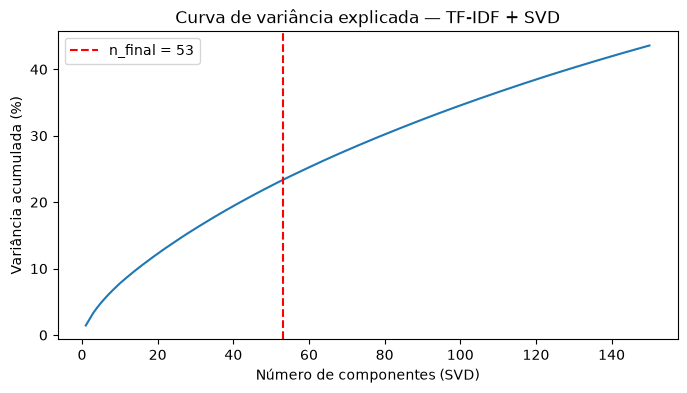

In [129]:
mask_real = ohe_df['description'].notna()
textos_reais = ohe_df.loc[mask_real, 'description']

print(f"Total de linhas: {len(ohe_df)}")
print(f"Linhas com descrição real: {mask_real.sum()}")
print(f"Linhas com 'missing_description': {(~mask_real).sum()}")

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(textos_reais)

svd_test = TruncatedSVD(n_components=150, random_state=42)
svd_test.fit(tfidf_matrix)

variancia_individual = svd_test.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_individual)

print(f"\nVariância acumulada com 150 componentes: {variancia_acumulada[-1]*100:.2f}%")
print("(Mostrando que mesmo 150 componentes não chegam perto de 80%)\n")

LIMIAR_GANHO_RELATIVO = 0.20
ganho_relativo = variancia_individual / variancia_individual[0]

condicao_cotovelo = ganho_relativo <= LIMIAR_GANHO_RELATIVO
if np.any(condicao_cotovelo):
    n_ideal = np.argmax(condicao_cotovelo) + 1
else:
    n_ideal = len(variancia_individual)

TETO_COMPONENTES = 100  # teto de segurança / custo computacional
n_final = min(n_ideal, TETO_COMPONENTES)

print(f"Componente onde o ganho marginal cai abaixo de {LIMIAR_GANHO_RELATIVO*100:.0f}% do 1º: {n_ideal}")
print(f"Variância acumulada nesse ponto: {variancia_acumulada[n_final-1]*100:.2f}%")
print(f"Componentes finais (com teto de segurança): {n_final}")

# Gráfico para visualizar o cotovelo
plt.figure(figsize=(8,4))
plt.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada*100)
plt.axvline(n_final, color='red', linestyle='--', label=f'n_final = {n_final}')
plt.xlabel('Número de componentes (SVD)')
plt.ylabel('Variância acumulada (%)')
plt.title('Curva de variância explicada — TF-IDF + SVD')
plt.legend()
plt.show()

In [130]:
def vectorize_descriptions(df: pd.DataFrame, n_components: int) -> pd.DataFrame:
    print("[Texto] Iniciando a vetorização das descrições...")
    
    mask_real = df['description'].notna()
    
    tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
    tfidf_matrix = tfidf.fit_transform(df.loc[mask_real, 'description'])
    
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    text_vectors_real = svd.fit_transform(tfidf_matrix)
    
    col_names = [f"desc_topic_{i}" for i in range(n_components)]
    
    text_vectors_full = np.zeros((len(df), n_components))
    text_vectors_full[mask_real.values] = text_vectors_real
    
    df_text = pd.DataFrame(text_vectors_full, columns=col_names, index=df.index)
    
    df = pd.concat([df, df_text], axis=1)
    df.drop(columns=['description'], inplace=True)
    
    print(f"[Texto] Descrições vetorizadas e reduzidas para {n_components} componentes principais.")
    return df

vectorized_df = vectorize_descriptions(ohe_df, n_components=n_final)

[Texto] Iniciando a vetorização das descrições...
[Texto] Descrições vetorizadas e reduzidas para 53 componentes principais.


In [131]:
vectorized_df.drop(["title"], axis=1, inplace=True)

In [ ]:
vectorized_df.to_csv("../data/bgg_dataset_tratado.csv", index=False)